# Step 1: Problem Framing & Theory Notes

## 1. What is Customer Churn? Why is predicting churn valuable for a business like Jio or Airtel?

### Customer Churn
Customer Churn refers to customers who stop using a company's services or switch to another provider.

### Why is Churn Prediction Important?

- Acquiring a new customer (Customer Acquisition Cost - **CAC**) is much more expensive than retaining an existing customer.
- Existing customers generate long-term revenue known as **Customer Lifetime Value (CLV)**.
- Predicting churn allows telecom companies to identify customers who are likely to leave.
- Companies can provide personalized offers and support to retain valuable customers, increasing profitability.

## 2. Confusion Matrix (TP, TN, FP, FN)

| Actual | Predicted | Meaning |
|---------|-----------|---------|
| TP | Churn | Customer actually churned and model predicted churn correctly. |
| TN | No Churn | Customer stayed and model predicted correctly. |
| FP | Churn | Model predicted churn but customer actually stayed. |
| FN | No Churn | Model predicted customer will stay but customer actually left. |

### Business Cost

- **False Negative (FN):** Most expensive because the company loses a customer without taking any retention action.
- **False Positive (FP):** Less expensive because the company may offer discounts to customers who would have stayed anyway.

## 3. What is Class Imbalance? How does SMOTE help?

### Class Imbalance
Class imbalance occurs when one class contains significantly more samples than the other.

### Telco Churn Dataset
The Telco Customer Churn dataset is imbalanced because the number of customers who do not churn is much larger than those who churn.

### SMOTE (Synthetic Minority Oversampling Technique)

- Creates synthetic samples for the minority class.
- Balances the training dataset.
- Improves the model's ability to predict churn customers.
- Reduces bias toward the majority class.

## 4. Brief Explanation of Algorithms

### K-Nearest Neighbors (KNN)
- KNN classifies a customer based on the majority class of its nearest neighbors.
- It is a distance-based algorithm and requires feature scaling.

### Naive Bayes
- Naive Bayes uses Bayes' Theorem assuming all features are independent.
- It is fast and performs well on many classification problems.

### Support Vector Machine (SVM)
- SVM finds the optimal hyperplane that separates different classes.
- It performs well for both linear and non-linear classification problems.

### Decision Tree
- Decision Tree splits the data into smaller groups using decision rules.
- It is easy to understand and interpret.

## 5. When would you choose Precision over Recall?

### Precision is preferred when:

- The cost of False Positives is very high.
- Example: If Jio can contact only a limited number of customers each day, it should contact customers who are highly likely to churn.

### Recall is generally more important for Churn Prediction because:

- Missing an actual churn customer (False Negative) results in customer loss.
- High Recall helps identify more customers who are likely to leave, allowing the company to take retention actions.

# Step 2: Dataset Loading & Exploratory Data Analysis

## 2.1  Load & Inspect

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [10]:
# load the dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
print("Shape of Dataset:", df.shape)

Shape of Dataset: (7043, 21)


- The dataset contains **7043 rows** and **21 columns**.
- Each row represents one telecom customer.
- The dataset size is sufficient for building classification models.

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [11]:
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [8]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [12]:
# Check Blank Spaces in TotalCharges
(df["TotalCharges"] == " ").sum()

np.int64(11)

In [15]:
# Replace Blank Spaces with NaN
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)

In [16]:
# Convert TotalCharges into Float
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

In [17]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

- Missing values are now visible in the **TotalCharges** column.
- These values were originally blank spaces.

In [18]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [20]:
# Check Class Balance
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [21]:
# Churn Percentage
churn_percentage = df["Churn"].value_counts(normalize=True) * 100
print(churn_percentage)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


- Around **73%** of customers did **not churn**.
- Around **27%** of customers **churned**.
- This indicates that the dataset is **imbalanced** because one class has significantly more observations than the other.

## 2.2  Univariate Analysis

C:\Users\Meet Anghan\AppData\Local\Temp\ipykernel_16996\3207506262.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Churn", data=df, palette="Set2")


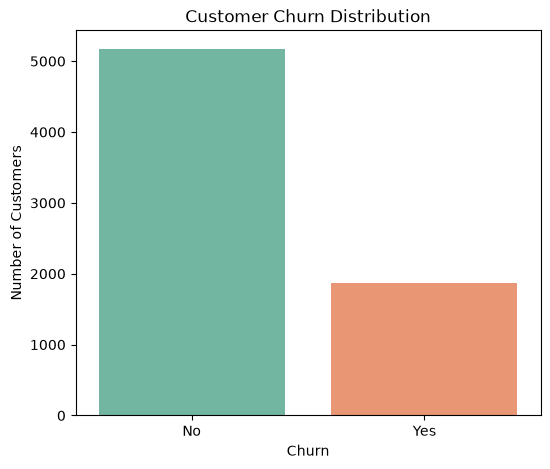

In [22]:
# Countplot of Target Variable (Churn)

plt.figure(figsize=(6,5))

sns.countplot(x="Churn", data=df, palette="Set2")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

- The majority of customers belong to the **No Churn** category.


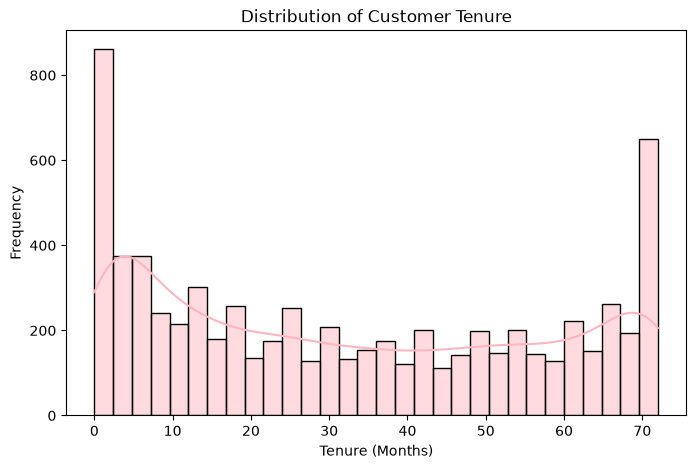

In [30]:
# Histogram of Tenure
plt.figure(figsize=(8,5))

sns.histplot(df["tenure"], bins=30, kde=True, color="lightpink")

plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Frequency")

plt.show()

- The tenure distribution is not uniform.


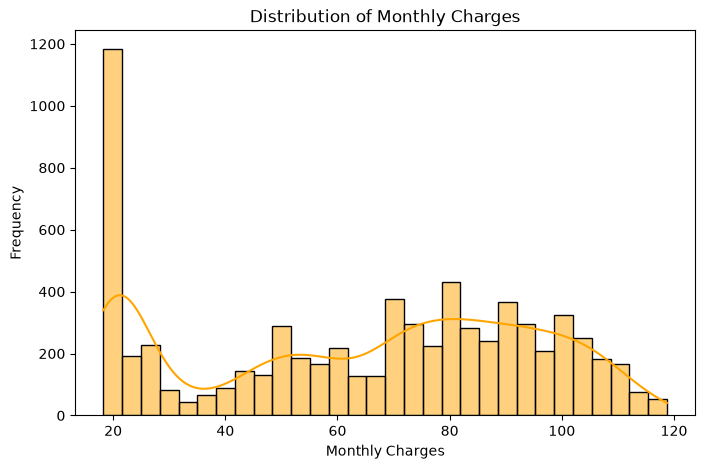

In [31]:
# Histogram of MonthlyCharges
plt.figure(figsize=(8,5))

sns.histplot(df["MonthlyCharges"], bins=30, kde=True, color="orange")

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Frequency")

plt.show()

- Monthly charges range from low to high values.


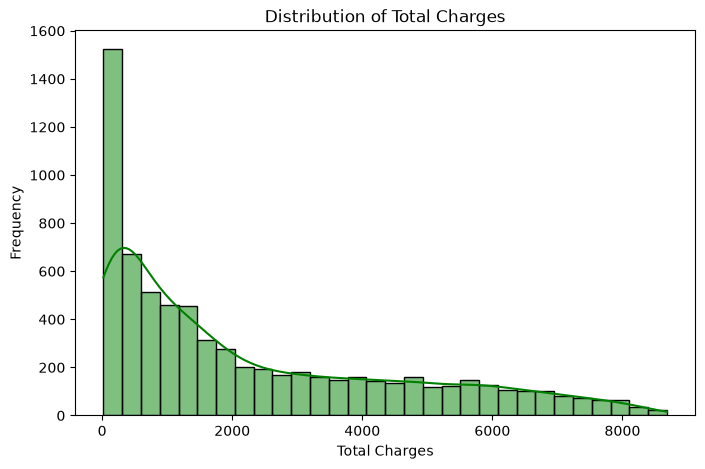

In [33]:
# Histogram of TotalCharges
plt.figure(figsize=(8,5))

sns.histplot(df["TotalCharges"], bins=30, kde=True, color="green")

plt.title("Distribution of Total Charges")
plt.xlabel("Total Charges")
plt.ylabel("Frequency")

plt.show()


- Total Charges show a right-skewed distribution.


C:\Users\Meet Anghan\AppData\Local\Temp\ipykernel_16996\2459709280.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Contract", data=df, palette="Set2")


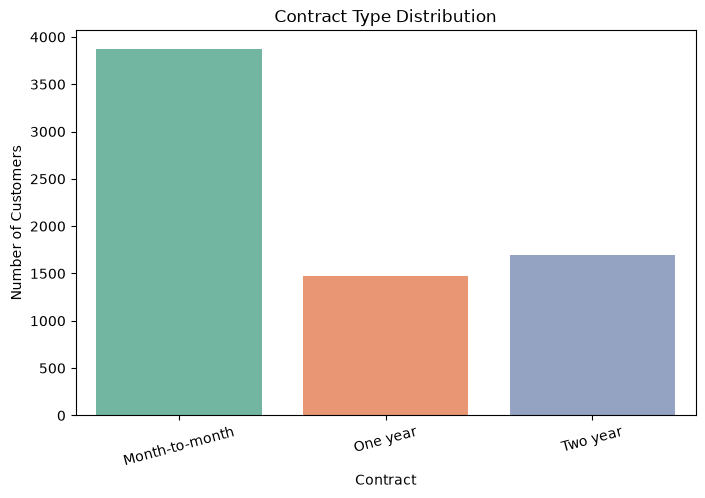

In [35]:
# Countplot of Contract
plt.figure(figsize=(8,5))

sns.countplot(x="Contract", data=df, palette="Set2")

plt.title("Contract Type Distribution")
plt.xlabel("Contract")
plt.ylabel("Number of Customers")

plt.xticks(rotation=15)

plt.show()

- **Month-to-Month** contracts are the most common.
- One-Year and Two-Year contracts have fewer customers.

C:\Users\Meet Anghan\AppData\Local\Temp\ipykernel_16996\4018725692.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="InternetService", data=df, palette="Set3")


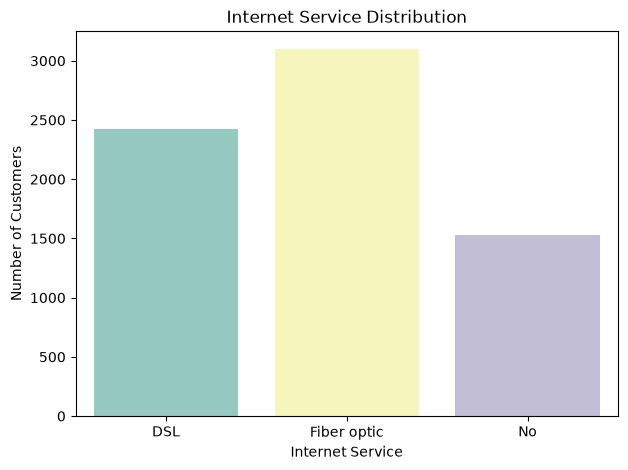

In [36]:
# Countplot of InternetService
plt.figure(figsize=(7,5))

sns.countplot(x="InternetService", data=df, palette="Set3")

plt.title("Internet Service Distribution")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

- Fiber Optic and DSL are the primary internet service types.


C:\Users\Meet Anghan\AppData\Local\Temp\ipykernel_16996\653494977.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="PaymentMethod", data=df, palette="Pastel1")


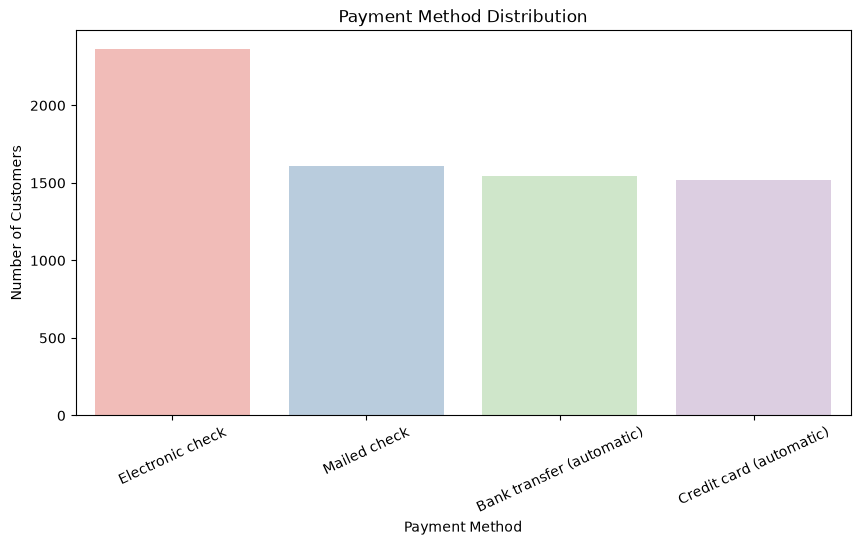

In [37]:
# Countplot of PaymentMethod
plt.figure(figsize=(10,5))

sns.countplot(x="PaymentMethod", data=df, palette="Pastel1")

plt.title("Payment Method Distribution")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.xticks(rotation=25)

plt.show()

- Customers use multiple payment methods.
- Electronic Check appears to be one of the most frequently used payment methods.

## 2.3  Bivariate Analysis

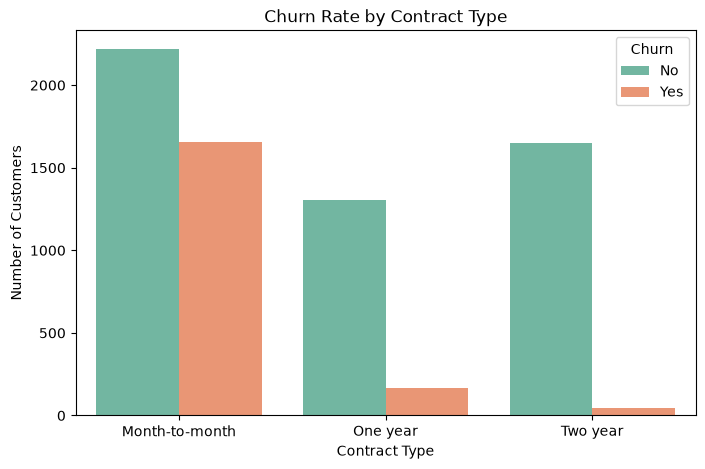

In [40]:
# Churn Rate by Contract Type (Grouped Bar Chart)
plt.figure(figsize=(8,5))

sns.countplot(x="Contract", hue="Churn", data=df, palette="Set2")

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

- Customers with **Month-to-Month** contracts have the highest churn rate.


In [41]:
# Create Tenure Buckets
bins = [0, 12, 24, 48, 72]
labels = ["0-12", "13-24", "25-48", "49-72"]

df["tenure_bucket"] = pd.cut(
    df["tenure"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

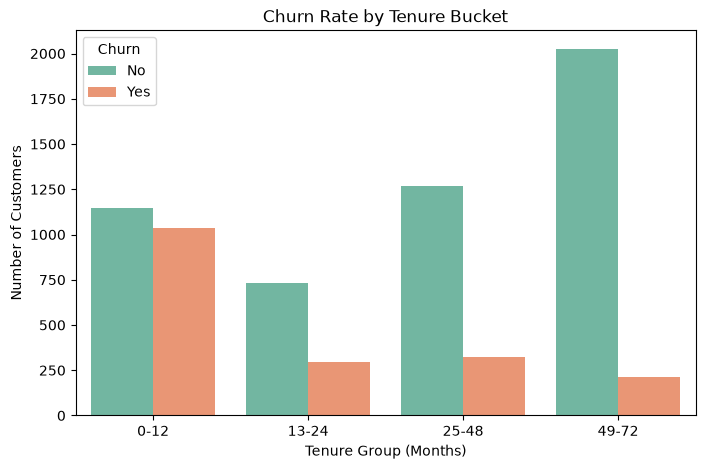

In [44]:
# Churn Rate by Tenure Bucket
plt.figure(figsize=(8,5))

sns.countplot(
    x="tenure_bucket",
    hue="Churn",
    data=df,
    palette="Set2"
)

plt.title("Churn Rate by Tenure Bucket")
plt.xlabel("Tenure Group (Months)")
plt.ylabel("Number of Customers")

plt.show()


- Customers with **0–12 months** tenure have the highest churn.

C:\Users\Meet Anghan\AppData\Local\Temp\ipykernel_16996\2326001171.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


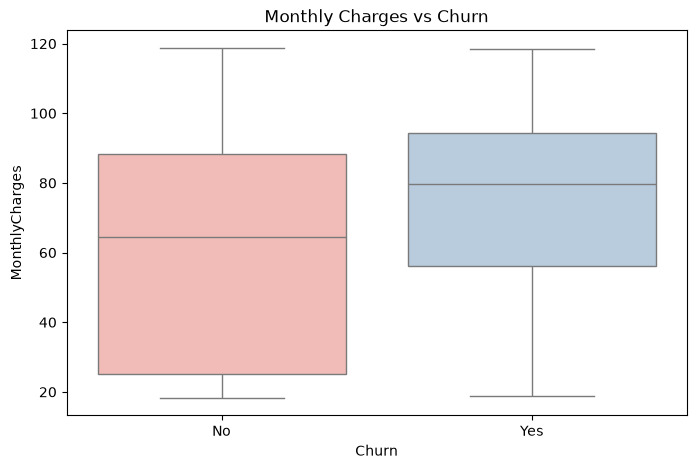

In [46]:
# Monthly Charges vs Churn (Boxplot)
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df,
    palette="Pastel1"
)

plt.title("Monthly Charges vs Churn")

plt.show()

- Customers who churn generally pay **higher monthly charges**.
- Higher monthly costs may increase customer dissatisfaction.
- Customers with expensive plans are more likely to switch providers.

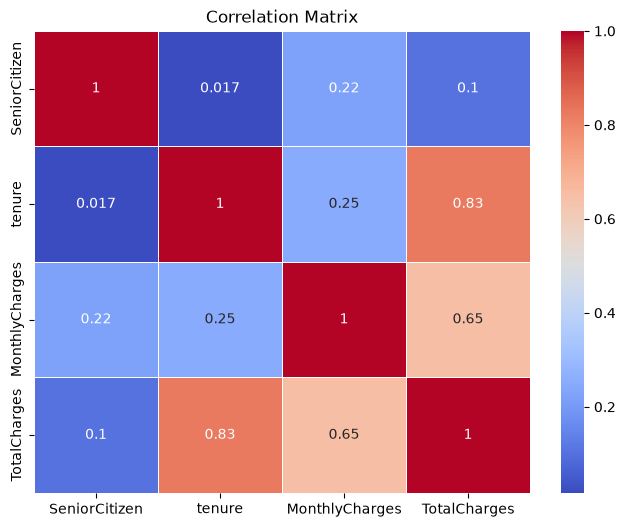

In [50]:
# Correlation Heatmap
numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix")

plt.show()

## Key Business Insight

The exploratory data analysis confirms that:

- Customers with **Month-to-Month contracts** are the most likely to churn.
- Customers with **low tenure (0–12 months)** have the highest churn rate.
- Customers paying **higher Monthly Charges** are more likely to leave the company.
- Long-term contract customers show much better retention.